# Why does the value-growth model work, and when doesn't it?

Notebook 05 established *that* the model ranks players by future value growth with a Spearman correlation around 0.55-0.6, consistently across nine years of walk-forward cutoffs. This notebook asks the harder questions underneath that number:

1. **Is it predicting football, or predicting transfers?** Transfermarkt re-values players straight after a move, usually toward the fee.
2. **Market drift vs. player signal.** How much error is "the whole market moved" rather than "we were wrong about this player"?
3. **Does the eye-test premium get corrected?** Do players valued above their stats subsequently lose value?
4. **Survivorship.** Players who leave the Premier League vanish from the outcome set. Who are they, and what happened to their value?
5. **Momentum or mean reversion?** The value-trend features were the biggest gain. Does "just went up" mean the same thing for a teenager and a star?
6. **The zero-change spike.** Is "not re-valued" informative, and does a two-stage model help?
7. **Relegation.** How much of the model's worst misses are an external shock it can't see?

All the evaluation here is walk-forward, reusing the harness from `src/modeling.py`; the diagnostics live in `src/analysis.py`.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from src.data_loader import download_dataset
from src.panel import HORIZON_TOLERANCE_DAYS, build_snapshot_panel, load_transfers
from src.modeling import (
    MARKET_FEATURES,
    NUMERIC_FEATURES,
    default_backtest_cutoffs,
    fit_model,
    modelable_rows,
    walk_forward_backtest,
)
from src.analysis import (
    add_stats_only_residual,
    augment_targets_with_other_leagues,
    flag_relegation_in_window,
    flag_transfers_within_horizon,
    grouped_backtest_metrics,
    market_drift_decomposition,
    partial_dependence_by_group,
    season_final_positions,
)

sns.set_theme(style="whitegrid", context="talk")
BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#888888"

panel = build_snapshot_panel()
data_dir = download_dataset()
cutoffs_12m = default_backtest_cutoffs(panel, months=12)
metrics_12m, preds_12m = walk_forward_backtest(panel, months=12, cutoffs=cutoffs_12m, model_names=("xgboost",))
print(f"{len(preds_12m):,} walk-forward predictions across {len(cutoffs_12m)} cutoffs; mean Spearman {metrics_12m['spearman'].mean():.2f}")

14,084 walk-forward predictions across 16 cutoffs; mean Spearman 0.59


## 1. Is the model predicting football, or predicting transfers?

Every player in the evaluation set is flagged by whether they changed club between the snapshot and the end of the outcome window. If the model only works on players who moved, its real skill is anticipating transfers, and its predicted "value growth" is largely the fee being written into the valuation.

In [2]:
transfers_raw = pd.read_csv(data_dir / "transfers.csv", low_memory=False)
transfers_raw["transfer_date"] = pd.to_datetime(transfers_raw["transfer_date"], errors="coerce")

flagged = flag_transfers_within_horizon(preds_12m, transfers_raw, months=12)
by_transfer = grouped_backtest_metrics(flagged, "transferred")

overall = (
    flagged.groupby("transferred")
    .apply(lambda g: pd.Series({
        "players": len(g),
        "share": len(g) / len(flagged),
        "mean_actual_change": g["actual_pct_change"].mean(),
        "median_actual_change": g["actual_pct_change"].median(),
        "share_unchanged": (g["actual_pct_change"] == 0).mean(),
    }), include_groups=False)
)
summary = by_transfer.groupby("transferred")[["spearman", "mae", "calibration_slope", "direction_accuracy"]].mean()
pd.concat([overall, summary], axis=1).round(3)

,players,share,mean_actual_change,median_actual_change,share_unchanged,spearman,mae,calibration_slope,direction_accuracy
transferred,,,,,,,,,
False,10059.0,0.714,0.225,-0.111,0.172,0.607,0.392,1.111,0.752
True,4025.0,0.286,0.379,-0.100,0.163,0.559,0.535,0.946,0.677


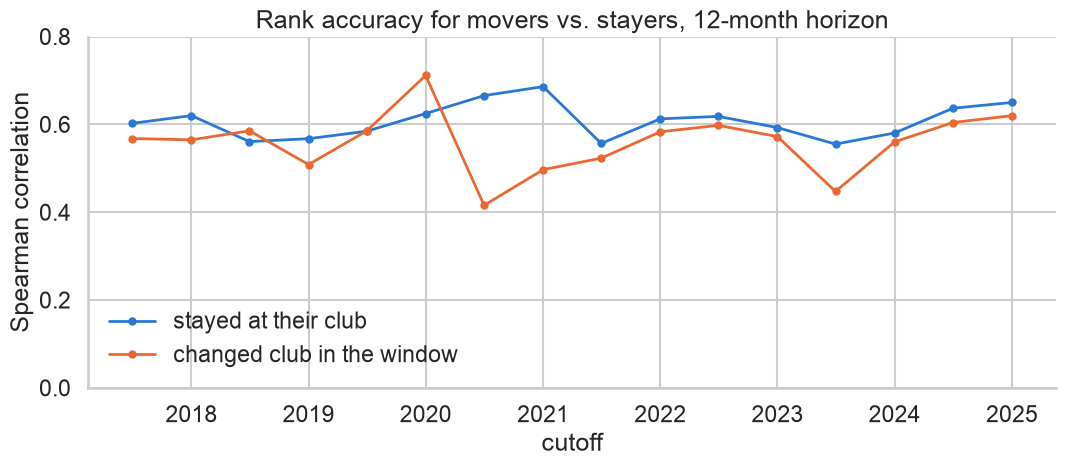

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
for flag, color, label in [(False, BLUE, "stayed at their club"), (True, ORANGE, "changed club in the window")]:
    rows = by_transfer[by_transfer["transferred"] == flag].sort_values("cutoff")
    ax.plot(rows["cutoff"], rows["spearman"], color=color, linewidth=2, marker="o", markersize=5, label=label)
ax.set_ylim(0, 0.8)
ax.set_ylabel("Spearman correlation")
ax.set_xlabel("cutoff")
ax.set_title("Rank accuracy for movers vs. stayers, 12-month horizon")
ax.legend(frameon=False, loc="lower left")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

The worry doesn't hold. About 29% of evaluated players changed club inside the window, and the model ranks the *other* 71% better, not worse: Spearman 0.61 for players who stayed against 0.56 for those who moved, with a lower error and better direction accuracy too. That pattern holds at 14 of the 16 cutoffs; the two exceptions (2020 and 2025) are the two cutoffs where movers were unusually well predicted, not where stayers failed.

So the skill is in reading age, form and valuation trajectory, and a transfer mostly adds noise on top: movers have a higher average realised change (+38% vs +23%) and a much wider spread, which is the fee landing wherever the negotiation ended. One nuance worth keeping in mind: movers are still a big enough slice that a scout using the top of the list would see plenty of them, and the model is *less* reliable about exactly those players.

## 2. Market-wide drift vs. player-specific error

Transfermarkt's valuations move together: everyone was marked down in spring 2020, and the whole league inflated through 2022-23. A model that only looks at the player can't see that, so some of its error is really "the market moved". This section separates the two. For each cutoff, the market-wide move is the average realised log change across all evaluated players; the model's implicit market forecast is the average of its predictions. Removing each cutoff's mean error from every prediction gives the error a model with perfect market foresight would have had.

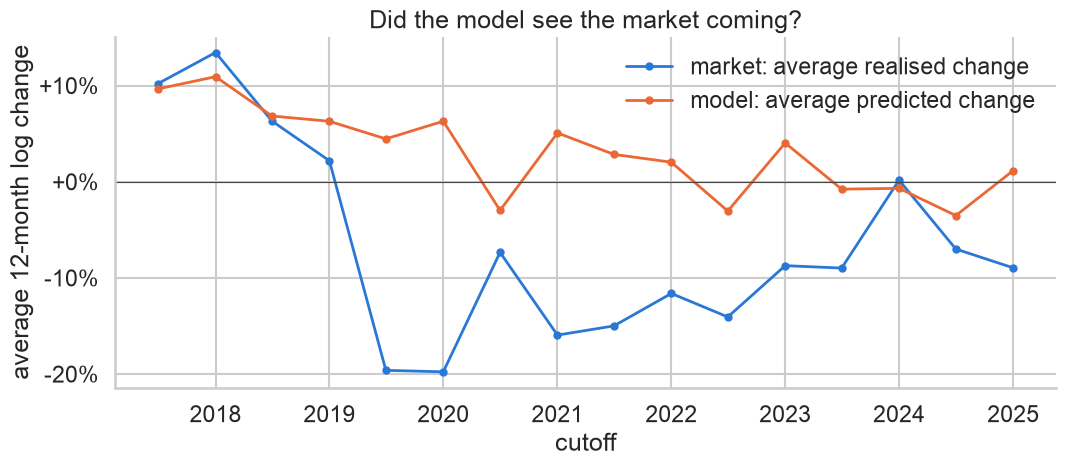

Mean absolute market bias: 0.101 log points
MAE 0.346 -> 0.326 with perfect market foresight (5% of error is market-wide on average; worst cutoff 22%)


,market_actual_log_change,market_predicted_log_change,market_bias,mae,mae_demeaned,share_of_mae_from_market
cutoff,,,,,,
2017-07-01,0.102,0.097,-0.006,0.347,0.347,-0.001
2018-01-01,0.134,0.109,-0.025,0.339,0.340,-0.003
2018-07-01,0.063,0.068,0.005,0.330,0.329,0.001
2019-01-01,0.022,0.063,0.041,0.361,0.356,0.015
2019-07-01,-0.196,0.045,0.241,0.395,0.325,0.177
2020-01-01,-0.198,0.063,0.261,0.383,0.300,0.218
2020-07-01,-0.073,-0.030,0.044,0.342,0.338,0.010
2021-01-01,-0.159,0.051,0.210,0.369,0.323,0.124
2021-07-01,-0.150,0.028,0.178,0.346,0.315,0.089


In [4]:
drift = market_drift_decomposition(preds_12m)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(drift["cutoff"], drift["market_actual_log_change"] * 100, color=BLUE, linewidth=2, marker="o", markersize=5, label="market: average realised change")
ax.plot(drift["cutoff"], drift["market_predicted_log_change"] * 100, color=ORANGE, linewidth=2, marker="o", markersize=5, label="model: average predicted change")
ax.axhline(0, color="#444444", linewidth=0.8)
ax.yaxis.set_major_formatter(lambda y, _: f"{y:+.0f}%")
ax.set_ylabel("average 12-month log change")
ax.set_xlabel("cutoff")
ax.set_title("Did the model see the market coming?")
ax.legend(frameon=False, loc="upper right")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(f"Mean absolute market bias: {drift['market_bias'].abs().mean():.3f} log points")
print(f"MAE {drift['mae'].mean():.3f} -> {drift['mae_demeaned'].mean():.3f} with perfect market foresight "
      f"({drift['share_of_mae_from_market'].mean():.0%} of error is market-wide on average; worst cutoff {drift['share_of_mae_from_market'].max():.0%})")
drift.set_index("cutoff")[["market_actual_log_change", "market_predicted_log_change", "market_bias", "mae", "mae_demeaned", "share_of_mae_from_market"]].round(3)

The chart is the honest picture of what a player-only model can and can't do. Up to 2019 the model's implicit market view tracked reality. Then the market fell about 20% in the pandemic windows and stayed negative for the average evaluated player through 2025, while the model kept assuming a flat-to-slightly-rising market it had learned from the pre-2019 years. It has been over-optimistic at every cutoff since mid-2019, by 0.1-0.26 log points at the worst.

And yet this is a small share of the total error: removing the market-wide bias entirely would cut MAE by only 5% on average, and 22% at the worst cutoff (January 2020). Most of the error is player-specific. That is good news for the model's ranking, which the market level can't affect, and bad news for anyone reading the predicted *sizes* literally in a falling market.

One caveat on the blue line: the evaluation set is each player's latest snapshot, including players not re-valued for up to a year, who skew older and declining. The "market" here is the market for evaluated Premier League players, not a league-wide index.

Can the model learn the drift? `market_trailing_12m_change` in the panel is the league-wide average log change over the year before each snapshot, strictly backward-looking. Adding it as a feature tells the model whether it is operating in a rising or falling market.

In [5]:
with_market = NUMERIC_FEATURES + MARKET_FEATURES
market_rows = []
for label, features in {"default features": NUMERIC_FEATURES, "+ market drift": with_market}.items():
    m, p = walk_forward_backtest(panel, months=12, cutoffs=cutoffs_12m, model_names=("ridge", "xgboost"), numeric_features=features)
    for model_name, mm in m.groupby("model"):
        bias = market_drift_decomposition(p[p["model"] == model_name])
        market_rows.append({
            "features": label, "model": model_name,
            "mae": mm["mae"].mean(), "spearman": mm["spearman"].mean(), "spearman_worst": mm["spearman"].min(),
            "calibration_slope": mm["calibration_slope"].mean(),
            "abs_market_bias": bias["market_bias"].abs().mean(),
        })
pd.DataFrame(market_rows).set_index(["features", "model"]).round(3)

mae  spearman  spearman_worst  calibration_slope  \
features         model                                                         
default features ridge    0.434     0.570           0.488              1.133   
                 xgboost  0.428     0.591           0.500              1.024   
+ market drift   ridge    0.422     0.571           0.492              1.253   
                 xgboost  0.421     0.596           0.506              1.177   

                          abs_market_bias  
features         model                     
default features ridge              0.103  
                 xgboost            0.101  
+ market drift   ridge              0.080  
                 xgboost            0.098

It helps, a little, and not in the way one might hope. MAE improves by about 1.5% for XGBoost and 3% for ridge, and the ridge model's market bias falls by a fifth. But XGBoost's bias barely moves, and both models' calibration gets worse (slope from 1.02 to 1.18 for XGBoost), meaning the feature is being used to shrink predictions rather than to shift them with the market. The trailing year of league-wide changes is simply a weak forecast of the next year's: the 2020 markdown was a shock, not a trend.

The feature stays in the panel and available (`MARKET_FEATURES`), but out of the default set. A proper fix would need something external to the valuations themselves: broadcast revenue, transfer spending totals, or macro conditions, none of which are in this dataset.

## 3. Does the eye-test premium get corrected?

Notebook 03 measured how far above or below their on-pitch stats each player is valued: a stats-only model predicts log value from age, output, minutes, team context and role, and the residual is what the market adds or subtracts on top. Here that residual is recomputed so it only ever looks backwards (a model fit on all snapshots before each calendar year predicts that year), which lets it be used as an input to the growth model without leakage.

The question: if a player is valued well above their stats today, does the market correct that over the next year (residual predicts *decline*), or does the premium persist because it reflects something real the stats don't capture?

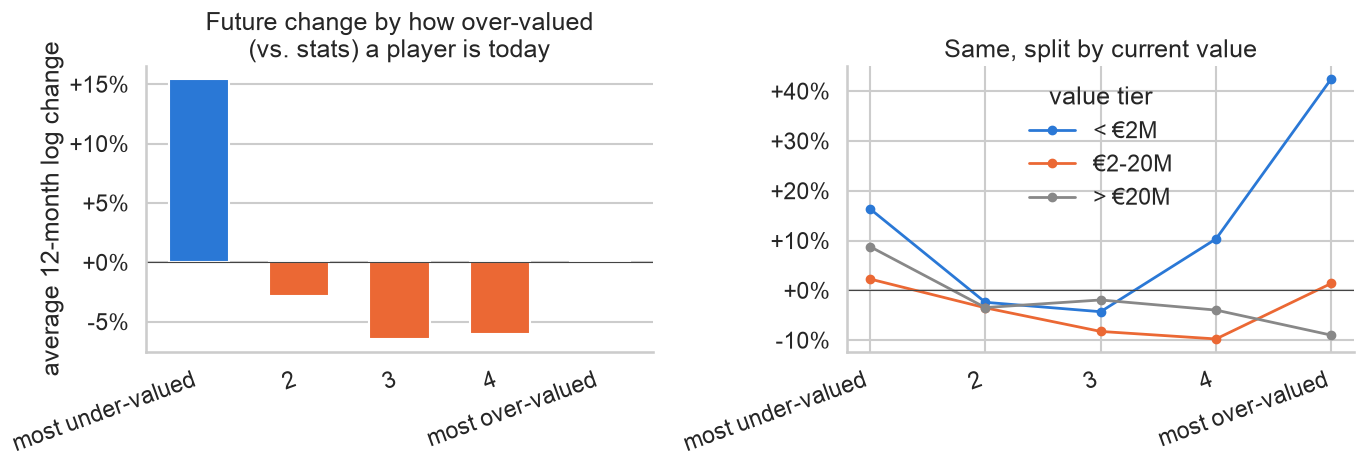

,n,mean_residual,future_log_change,share_rose,share_fell
residual_quintile,,,,,
most under-valued,4826,-0.600,0.155,0.390,0.357
2,4825,-0.150,-0.029,0.325,0.483
3,4826,0.084,-0.065,0.337,0.513
4,4825,0.279,-0.061,0.344,0.519
most over-valued,4826,0.644,0.002,0.386,0.475


In [6]:
panel_res = add_stats_only_residual(panel)
has_res = panel_res.dropna(subset=["stats_residual", "value_change_12m_pct"]).copy()
has_res["future_log_change"] = np.log1p(has_res["value_change_12m_pct"].clip(-0.95, 5))
has_res["residual_quintile"] = pd.qcut(has_res["stats_residual"], 5, labels=["most under-valued", "2", "3", "4", "most over-valued"])
has_res["value_tier"] = pd.cut(has_res["current_value_eur"], [0, 2e6, 20e6, np.inf], labels=["< €2M", "€2-20M", "> €20M"])

by_quintile = has_res.groupby("residual_quintile", observed=True).agg(
    n=("player_id", "size"),
    mean_residual=("stats_residual", "mean"),
    future_log_change=("future_log_change", "mean"),
    share_rose=("value_change_12m_pct", lambda s: (s > 0).mean()),
    share_fell=("value_change_12m_pct", lambda s: (s < 0).mean()),
)
by_tier = has_res.groupby(["value_tier", "residual_quintile"], observed=True)["future_log_change"].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(5)
axes[0].bar(x, by_quintile["future_log_change"] * 100, color=[ORANGE if v < 0 else BLUE for v in by_quintile["future_log_change"]], width=0.6)
axes[0].axhline(0, color="#444444", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(by_quintile.index, rotation=20, ha="right")
axes[0].yaxis.set_major_formatter(lambda y, _: f"{y:+.0f}%")
axes[0].set_ylabel("average 12-month log change")
axes[0].set_title("Future change by how over-valued\n(vs. stats) a player is today")
sns.despine(ax=axes[0])
axes[0].grid(axis="x", visible=False)

for tier, color in zip(by_tier.index, [BLUE, ORANGE, GREY]):
    axes[1].plot(x, by_tier.loc[tier] * 100, color=color, linewidth=2, marker="o", markersize=6, label=tier)
axes[1].axhline(0, color="#444444", linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(by_tier.columns, rotation=20, ha="right")
axes[1].yaxis.set_major_formatter(lambda y, _: f"{y:+.0f}%")
axes[1].set_title("Same, split by current value")
axes[1].legend(frameon=False, title="value tier")
sns.despine(ax=axes[1])
plt.tight_layout()
plt.show()
by_quintile.round(3)

The answer is asymmetric, and it isn't the "over-valued players get found out" story. The most *under*-valued fifth (valued about four times below what their stats suggest) rose 15% on average over the following year, while every other fifth was flat to slightly down. The most *over*-valued fifth did not fall: its average change is zero, and almost as many of those players rose as fell. The market corrects under-valuation, re-rating players whose output has outrun their price, but the premium it pays above the stats persists. Whatever it sees in those players, it keeps seeing.

The split by value tier explains part of why. Among cheap players (under €2M) the most over-valued fifth rose strongly, by over 40%. Those are academy prospects priced on potential, and the "premium" is the market pricing information (age, pedigree, minutes in youth competitions) that a stats-only model built on senior output cannot see. Their subsequent rise says the market was right, not irrational. Only at the top of the market, above €20M, does the most over-valued fifth drift down, by about 9%, which is the one place a mild correction shows up. Notebook 03's big-six premium sits in that population, so "big-six players are over-valued" is, at most, a slow-leaking mispricing rather than a bubble.

Does the growth model benefit from knowing the residual? Walk-forward, on the same rows (those with a residual available), with and without it as a feature:

In [7]:
res_rows = []
for label, features in {"default features": NUMERIC_FEATURES, "+ stats residual": NUMERIC_FEATURES + ["stats_residual"]}.items():
    m, _ = walk_forward_backtest(panel_res.dropna(subset=["stats_residual"]), months=12, cutoffs=cutoffs_12m, model_names=("ridge", "xgboost"), numeric_features=features)
    g = m.groupby("model").agg(mae=("mae", "mean"), spearman=("spearman", "mean"), spearman_worst=("spearman", "min"), calibration_slope=("calibration_slope", "mean"))
    g.insert(0, "features", label)
    res_rows.append(g.reset_index())
pd.concat(res_rows).set_index(["features", "model"]).round(3)

mae  spearman  spearman_worst  calibration_slope
features         model                                                      
default features ridge    0.427     0.578           0.496              1.217
                 xgboost  0.424     0.591           0.504              1.088
+ stats residual ridge    0.426     0.581           0.500              1.217
                 xgboost  0.423     0.591           0.500              1.084

Nothing. Spearman and MAE are unchanged to the third decimal for both models. The growth model already sees current value and the same on-pitch stats, so the residual is a combination of inputs it can reconstruct on its own. The finding above is descriptive, about how the market behaves, rather than a new source of predictive signal.

## 4. Survivorship: the players who disappear

The panel matches each outcome against *Premier League* valuations. A player who leaves for Serie A, or drops out of a tracked league entirely, has no outcome and is silently excluded from every accuracy number so far. Two questions: who are they, and what happened to their value? The second is partly answerable, because Transfermarkt keeps valuing players wherever they go, and the raw valuations file covers every league.

In [8]:
valuations_all = pd.read_csv(data_dir / "player_valuations.csv")
valuations_all["date"] = pd.to_datetime(valuations_all["date"], errors="coerce")
augmented = augment_targets_with_other_leagues(panel, valuations_all, months=12)

data_end = panel["snapshot_date"].max()
resolvable = augmented[augmented["snapshot_date"] + pd.DateOffset(months=12) + pd.Timedelta(days=HORIZON_TOLERANCE_DAYS[12]) <= data_end]
status_counts = resolvable["target_source_12m"].value_counts()
print("Snapshots old enough to have a 12-month outcome, by where that outcome was found:")
print((status_counts / status_counts.sum()).round(3).to_string())

profile = resolvable.groupby("target_source_12m").agg(
    n=("player_id", "size"),
    median_age=("age", "median"),
    median_value_eur_m=("current_value_eur", lambda s: s.median() / 1e6),
    median_trailing_minutes=("trailing_minutes", "median"),
    share_no_pl_minutes=("trailing_minutes", lambda s: (s == 0).mean()),
    median_value_vs_peak=("value_vs_peak", "median"),
    mean_prev_change=("prev_value_change_pct", "mean"),
).loc[["pl", "other_league", "none"]]
profile.round(3)

Snapshots old enough to have a 12-month outcome, by where that outcome was found:
target_source_12m
pl              0.814
none            0.126
other_league    0.060


,n,median_age,median_value_eur_m,median_trailing_minutes,share_no_pl_minutes,median_value_vs_peak,mean_prev_change
target_source_12m,,,,,,,
pl,25123,25.955,3.5,0.0,0.526,0.955,0.257
other_league,1847,25.525,6.0,213.0,0.378,0.833,0.053
none,3903,25.785,0.5,0.0,0.834,0.833,0.221


Where the leavers turned up: {'ES1': 295, 'FR1': 237, 'IT1': 222, 'L1': 192, 'TR1': 161, 'SC1': 114, 'NL1': 100, 'BE1': 86}


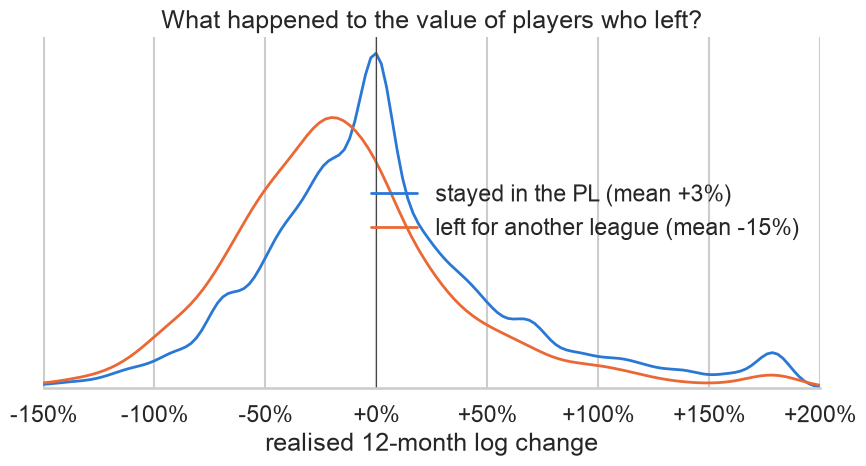

In [9]:
leavers = resolvable[resolvable["target_source_12m"] == "other_league"]
print("Where the leavers turned up:", leavers["future_league_12m"].value_counts().head(8).to_dict())

fig, ax = plt.subplots(figsize=(9, 5))
for source, color, label in [("pl", BLUE, "stayed in the PL"), ("other_league", ORANGE, "left for another league")]:
    vals = np.log1p(resolvable.loc[resolvable["target_source_12m"] == source, "value_change_12m_pct"].clip(-0.95, 5)) * 100
    sns.kdeplot(vals, ax=ax, color=color, linewidth=2, label=f"{label} (mean {vals.mean():+.0f}%)")
ax.axvline(0, color="#444444", linewidth=0.8)
ax.set_xlim(-150, 200)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:+.0f}%")
ax.set_xlabel("realised 12-month log change")
ax.set_ylabel("")
ax.set_yticks([])
ax.set_title("What happened to the value of players who left?")
ax.legend(frameon=False, loc="center right")
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

About 81% of snapshots old enough to have a 12-month outcome do have one in the Premier League data. Of the rest, 6% turn up valued in another league inside the matching window, and 12.6% are never re-valued anywhere in time.

Those two missing groups are very different players. The never-re-valued group is the fringe: median value €0.5M, and 83% had no Premier League minutes in the previous year. These are academy and squad players dropping out of tracked football or into lower leagues, and for them no outcome exists to measure. The leavers are the opposite: *more* valuable than the players who stayed (median €6M against €3.5M), with more minutes, but further below their career peak and with a flat recent trend. Established players past their best, moving on to Spain, France, Italy and Germany most often.

And their values fell. On the log scale, leavers averaged about -15% over the year against +3% for stayers, with the whole distribution shifted left. A move out of the Premier League is, on average, a step down in valuation, partly because Transfermarkt prices the league a player is in.

Now the accuracy question. Re-running the walk-forward backtest on the augmented panel puts the leavers back into both training and evaluation. If the model's scores hold up on them, survivorship wasn't flattering the headline numbers.

In [10]:
aug_metrics, aug_preds = walk_forward_backtest(augmented, months=12, cutoffs=cutoffs_12m, model_names=("xgboost",))
aug_preds = aug_preds.merge(augmented[["player_id", "snapshot_date", "target_source_12m"]], on=["player_id", "snapshot_date"], how="left")
by_source = grouped_backtest_metrics(aug_preds, "target_source_12m")

comparison = pd.DataFrame({
    "PL outcomes only (notebook 05)": metrics_12m[["mae", "spearman", "calibration_slope", "direction_accuracy"]].mean(),
    "PL + other-league outcomes": aug_metrics[["mae", "spearman", "calibration_slope", "direction_accuracy"]].mean(),
}).T
display(comparison.round(3))
print("Within the augmented backtest, by where the outcome came from:")
by_source.groupby("target_source_12m")[["share", "spearman", "mae", "calibration_slope", "direction_accuracy", "mean_actual_all"]].mean().round(3)

,mae,spearman,calibration_slope,direction_accuracy
PL outcomes only (notebook 05),0.428,0.591,1.024,0.732
PL + other-league outcomes,0.432,0.565,1.031,0.724


Within the augmented backtest, by where the outcome came from:


,share,spearman,mae,calibration_slope,direction_accuracy,mean_actual_all
target_source_12m,,,,,,
other_league,0.139,0.402,0.436,0.899,0.639,0.053
pl,0.861,0.588,0.431,1.039,0.736,0.292


Survivorship *was* flattering the headline, modestly. Adding the leavers' real outcomes lowers the 12-month Spearman from 0.59 to 0.565 and nudges MAE up. On the leavers alone the model manages a Spearman of only 0.40: it can rank them, but it has no way to anticipate the league change that drives much of their decline. Calibration is unaffected.

The honest reading of notebook 05's headline is therefore a range. The Spearman is about 0.59 for players who stay in the league, about 0.565 across everyone whose outcome can be observed, and unknown for the 12.6% who were never re-valued. Given that group's profile (cheap, unused), their values most likely fell, and the model tends to predict declines for players with no minutes, so the true number probably sits near the lower end of that range rather than below it. That is still far from chance, but it is a smaller number than the one a PL-only evaluation reports.

## 5. Momentum or mean reversion?

The value-trend features (the size of a player's last re-valuation, and where they sit relative to their peak) were the largest single improvement to the model. But "just went up 50%" plausibly means different things for a €1M teenager and a €60M star. This looks at the raw data first, then at what the fitted model actually does with the feature for each kind of player.

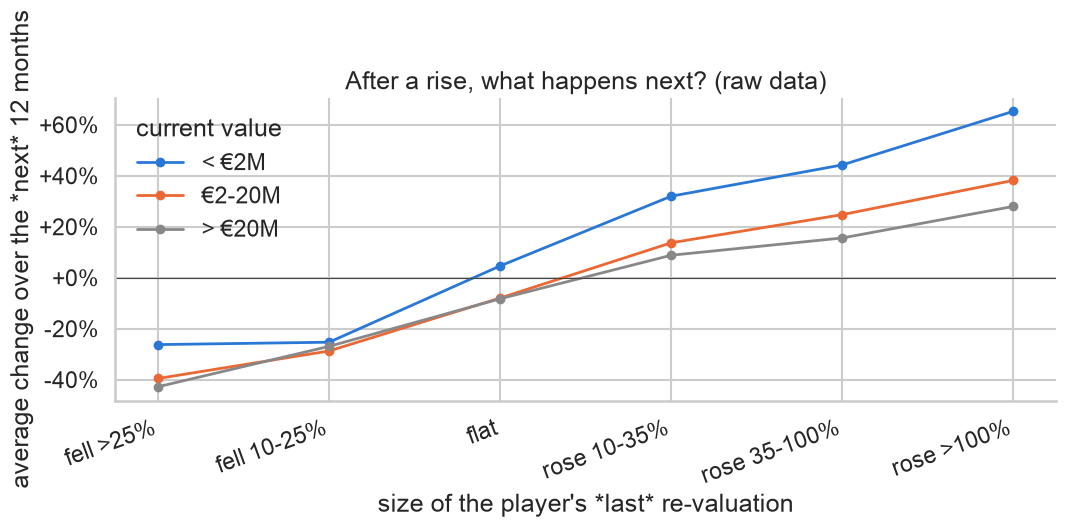

players per cell:


last_move,fell >25%,fell 10-25%,flat,rose 10-35%,rose 35-100%,rose >100%
value_tier,,,,,,
< €2M,1331,1761,3295,754,690,999
€2-20M,756,2826,4417,1919,1206,718
> €20M,37,676,1573,847,262,44


In [11]:
trend = panel[(panel["has_prev_valuation"] == 1) & panel["value_change_12m_pct"].notna()].copy()
trend["future_log_change"] = np.log1p(trend["value_change_12m_pct"].clip(-0.95, 5))
trend["last_move"] = pd.cut(
    np.log1p(trend["prev_value_change_pct"].clip(lower=-0.99)),
    [-np.inf, -0.29, -0.1, 0.1, 0.29, 0.69, np.inf],
    labels=["fell >25%", "fell 10-25%", "flat", "rose 10-35%", "rose 35-100%", "rose >100%"],
)
trend["value_tier"] = pd.cut(trend["current_value_eur"], [0, 2e6, 20e6, np.inf], labels=["< €2M", "€2-20M", "> €20M"])

empirical = trend.groupby(["value_tier", "last_move"], observed=True)["future_log_change"].agg(["mean", "size"])
counts = empirical["size"].unstack()
means = empirical["mean"].unstack()

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(means.shape[1])
for tier, color in zip(means.index, [BLUE, ORANGE, GREY]):
    ax.plot(x, means.loc[tier] * 100, color=color, linewidth=2, marker="o", markersize=6, label=tier)
ax.axhline(0, color="#444444", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(means.columns, rotation=20, ha="right")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:+.0f}%")
ax.set_ylabel("average change over the *next* 12 months")
ax.set_xlabel("size of the player's *last* re-valuation")
ax.set_title("After a rise, what happens next? (raw data)")
ax.legend(frameon=False, title="current value")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()
print("players per cell:")
counts

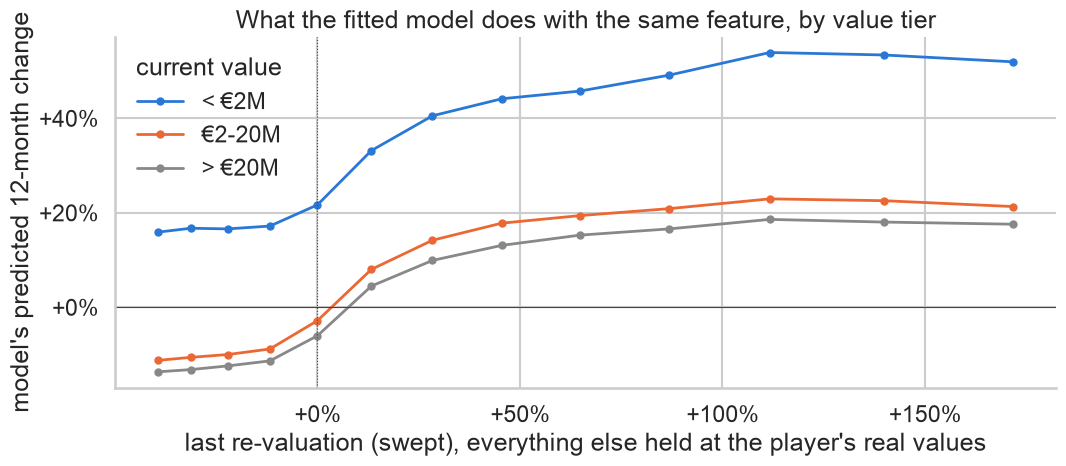

In [12]:
growth_model = fit_model(modelable_rows(panel, months=12), "xgboost", months=12)
sample = modelable_rows(panel, months=12).sample(4000, random_state=0)
tier = pd.cut(sample["current_value_eur"], [0, 2e6, 20e6, np.inf], labels=["< €2M", "€2-20M", "> €20M"])
grid = np.linspace(-0.5, 1.0, 13)
pdp = partial_dependence_by_group(growth_model, sample, "log_prev_value_ratio", grid, tier)

fig, ax = plt.subplots(figsize=(11, 5))
for t, color in zip(pdp.index, [BLUE, ORANGE, GREY]):
    ax.plot((np.exp(grid) - 1) * 100, pdp.loc[t] * 100, color=color, linewidth=2, marker="o", markersize=5, label=t)
ax.axhline(0, color="#444444", linewidth=0.8)
ax.axvline(0, color="#444444", linewidth=0.8, linestyle=":")
ax.xaxis.set_major_formatter(lambda v, _: f"{v:+.0f}%")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:+.0f}%")
ax.set_xlabel("last re-valuation (swept), everything else held at the player's real values")
ax.set_ylabel("model's predicted 12-month change")
ax.set_title("What the fitted model does with the same feature, by value tier")
ax.legend(frameon=False, title="current value")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

It is momentum, at every price. In the raw data the relationship is monotonic and steep for all three tiers: players whose last re-valuation was a fall of more than 25% went on to lose another 25-45% on average, and players who had just doubled went on to gain another 30-65%. There is no reversion anywhere in the range. The tiers differ in degree, not kind: cheap players ride momentum hardest, and after a fall they fall less (about -26%, against -40% for the more expensive tiers), consistent with young players' values having a floor while established players' decline has none.

The fitted model has learned the same thing, with one refinement the raw averages hide: the effect is a step, not a slope. Sweeping the last re-valuation from -40% to -10% barely changes the prediction, then it jumps between 0 and +50%, then it saturates. In other words the model reads the feature almost as a three-way flag ("recently cut", "untouched", "recently raised") and reserves the biggest response for cheap players, for whom a first upward re-valuation is the market's signal that a prospect has been noticed. That step shape is also why the linear models gained less from this feature than XGBoost did in notebook 05.

## 6. The zero-change spike: is "not re-valued" informative?

A large share of outcomes are *exactly* zero: Transfermarkt looked at the player and left the number alone. That is a decision, not missing data, and it tends to happen to particular kinds of players. If so, a model that predicts "will the value move at all?" separately from "by how much?" (a hurdle model, `HurdleRegressor` in `src/modeling.py`) should describe the data better than a single regression.

Share of 12-month outcomes that are exactly zero: 16.6%


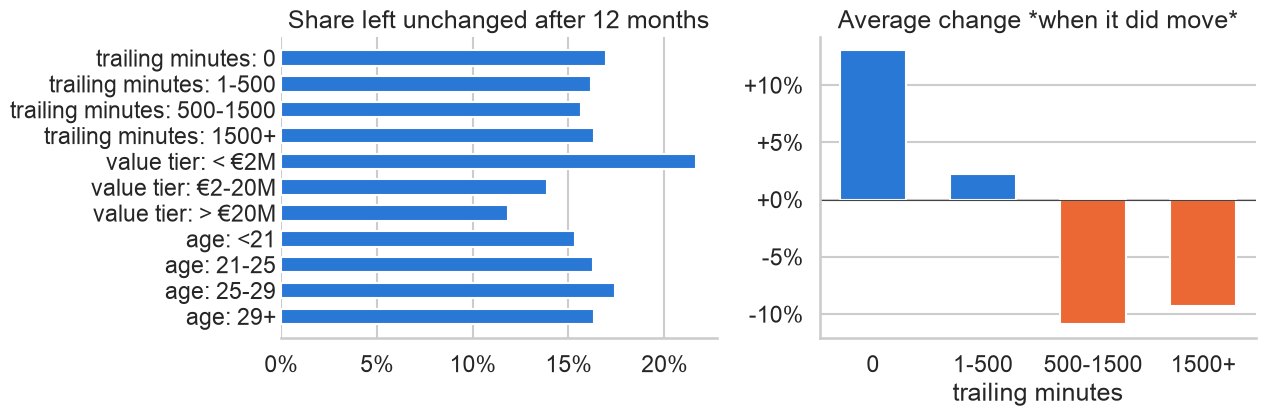

In [13]:
zero = panel[panel["value_change_12m_pct"].notna()].copy()
zero["unchanged"] = zero["value_change_12m_pct"] == 0
zero["minutes_bucket"] = pd.cut(zero["trailing_minutes"], [-1, 0, 500, 1500, np.inf], labels=["0", "1-500", "500-1500", "1500+"])
zero["value_tier"] = pd.cut(zero["current_value_eur"], [0, 2e6, 20e6, np.inf], labels=["< €2M", "€2-20M", "> €20M"])
zero["age_band"] = pd.cut(zero["age"], [0, 21, 25, 29, 50], labels=["<21", "21-25", "25-29", "29+"])

print(f"Share of 12-month outcomes that are exactly zero: {zero['unchanged'].mean():.1%}")
share_by = pd.concat({
    "trailing minutes": zero.groupby("minutes_bucket", observed=True)["unchanged"].mean(),
    "value tier": zero.groupby("value_tier", observed=True)["unchanged"].mean(),
    "age": zero.groupby("age_band", observed=True)["unchanged"].mean(),
})
moved_mean = zero[~zero["unchanged"]].groupby("minutes_bucket", observed=True)["value_change_12m_pct"].apply(lambda s: np.log1p(s.clip(-0.95, 5)).mean())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].barh(range(len(share_by)), share_by.values * 100, color=BLUE, height=0.6)
axes[0].set_yticks(range(len(share_by)))
axes[0].set_yticklabels([f"{a}: {b}" for a, b in share_by.index])
axes[0].invert_yaxis()
axes[0].xaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
axes[0].set_title("Share left unchanged after 12 months")
sns.despine(ax=axes[0], left=True)
axes[0].tick_params(axis="y", length=0)
axes[0].grid(axis="y", visible=False)

axes[1].bar(range(len(moved_mean)), moved_mean.values * 100, color=[ORANGE if v < 0 else BLUE for v in moved_mean.values], width=0.6)
axes[1].axhline(0, color="#444444", linewidth=0.8)
axes[1].set_xticks(range(len(moved_mean)))
axes[1].set_xticklabels(moved_mean.index)
axes[1].yaxis.set_major_formatter(lambda y, _: f"{y:+.0f}%")
axes[1].set_xlabel("trailing minutes")
axes[1].set_title("Average change *when it did move*")
sns.despine(ax=axes[1])
axes[1].grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

In [14]:
hurdle_rows = []
for months in (12, 3):
    cutoffs = default_backtest_cutoffs(panel, months=months)
    m, _ = walk_forward_backtest(panel, months=months, cutoffs=cutoffs, model_names=("xgboost", "hurdle"))
    g = m.groupby("model").agg(mae=("mae", "mean"), spearman=("spearman", "mean"), spearman_worst=("spearman", "min"), calibration_slope=("calibration_slope", "mean"), direction_accuracy=("direction_accuracy", "mean"))
    g.insert(0, "months", months)
    hurdle_rows.append(g.reset_index())
pd.concat(hurdle_rows).set_index(["months", "model"]).round(3)

mae  spearman  spearman_worst  calibration_slope  \
months model                                                         
12     hurdle   0.429     0.590           0.507              1.037   
       xgboost  0.428     0.591           0.500              1.024   
3      hurdle   0.206     0.668           0.581              0.994   
       xgboost  0.205     0.662           0.587              1.032   

                direction_accuracy  
months model                        
12     hurdle                0.733  
       xgboost               0.732  
3      hurdle                0.842  
       xgboost               0.841

One in six 12-month outcomes is an unchanged valuation. But it is not very informative *who* gets left alone: the share is flat across minutes played (15-17% whether a player played nothing or every game) and across age, and varies only with price, from 21% of players under €2M to 12% of players above €20M. Transfermarkt's editors revisit expensive players more often; beyond that, "unchanged" is close to random. The right-hand chart carries the more interesting fact: among players with *no* league minutes whose value did move, the average move was up (+13%), while among regulars who moved it was down. The first group are prospects getting their first re-ratings; the second are established players ageing.

Because the zero is close to random, the two-stage model has nothing to gain. Walk-forward it is indistinguishable from the plain regression at both horizons, to the third decimal on MAE and Spearman. The spike in the histogram is real, but a single model handles it fine.

## 7. Relegation: a shock the model can't see

Trailing club league position is a feature, but relegation is a discontinuity: a good player at a relegated club loses value regardless of their own output, because Transfermarkt prices the division. The games table gives every club's standing on the final matchday, so each walk-forward prediction can be flagged by whether the player's club (as of the snapshot) went down at the end of a season inside the outcome window.

,players,share,mean_actual_log_change,mean_predicted_log_change,mean_log_error,mae_log
club_relegated_in_window,,,,,,
False,12316,0.874,-0.058,0.039,0.097,0.349
True,1768,0.126,-0.165,-0.022,0.144,0.343


Relegated-club players are 12.6% of all predictions but 12.5% of the 5% worst over-predictions.


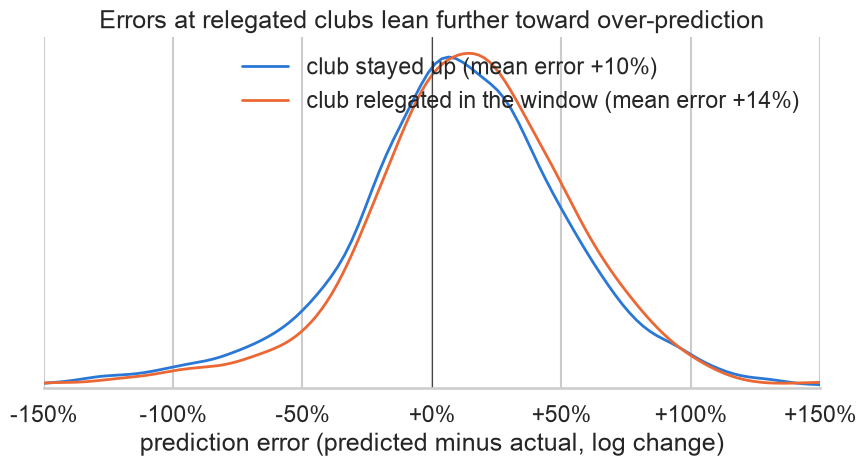

In [15]:
games = pd.read_csv(data_dir / "games.csv")
final_positions = season_final_positions(games)

preds_club = preds_12m.merge(panel[["player_id", "snapshot_date", "current_club_id"]], on=["player_id", "snapshot_date"], how="left")
preds_club = flag_relegation_in_window(preds_club, final_positions, months=12)
preds_club["log_error"] = np.log1p(preds_club["predicted_pct_change"].clip(-0.95, 5)) - np.log1p(preds_club["actual_pct_change"].clip(-0.95, 5))

by_releg = preds_club.groupby("club_relegated_in_window").agg(
    players=("player_id", "size"),
    share=("player_id", lambda s: len(s) / len(preds_club)),
    mean_actual_log_change=("actual_pct_change", lambda s: np.log1p(s.clip(-0.95, 5)).mean()),
    mean_predicted_log_change=("predicted_pct_change", lambda s: np.log1p(s.clip(-0.95, 5)).mean()),
    mean_log_error=("log_error", "mean"),
    mae_log=("log_error", lambda e: e.abs().mean()),
)
display(by_releg.round(3))

worst = preds_club.nlargest(int(len(preds_club) * 0.05), "log_error")  # biggest over-predictions
print(f"Relegated-club players are {preds_club['club_relegated_in_window'].mean():.1%} of all predictions "
      f"but {worst['club_relegated_in_window'].mean():.1%} of the 5% worst over-predictions.")

fig, ax = plt.subplots(figsize=(9, 5))
for flag, color, label in [(False, BLUE, "club stayed up"), (True, ORANGE, "club relegated in the window")]:
    vals = preds_club.loc[preds_club["club_relegated_in_window"] == flag, "log_error"] * 100
    sns.kdeplot(vals, ax=ax, color=color, linewidth=2, label=f"{label} (mean error {vals.mean():+.0f}%)")
ax.axvline(0, color="#444444", linewidth=0.8)
ax.set_xlim(-150, 150)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:+.0f}%")
ax.set_xlabel("prediction error (predicted minus actual, log change)")
ax.set_ylabel("")
ax.set_yticks([])
ax.set_title("Errors at relegated clubs lean further toward over-prediction")
ax.legend(frameon=False, loc="upper right")
sns.despine(ax=ax, left=True)
plt.tight_layout()
plt.show()

About one in eight evaluated players was at a club that went down inside the outcome window, and their values fell by about 16% on average against 6% for everyone else. The model saw some of this coming: through trailing club position it predicted a small decline (-2%) for them where it predicted a small rise (+4%) for others. But it did not see enough. Its average over-prediction at relegated clubs is 14% against 10% elsewhere, a systematic 4-5 point shift.

What relegation is *not* is the source of the worst misses. Relegated-club players make up 12.6% of all predictions and 12.5% of the 5% largest over-predictions, so they are exactly proportionally represented. Relegation is a modest, predictable bias rather than a tail event, and a final-position or "relegation risk" feature would probably remove most of it. The truly large misses come from elsewhere: individual breakouts and collapses that no club-level variable explains.

## What this adds up to

- The model's skill is in reading players, not anticipating transfers: it ranks players who stay put *better* than those who move.
- Its errors are mostly player-specific. Market-wide drift is real, and it has been over-optimistic since the pandemic, but that is only about 5% of the error.
- The market corrects players it under-values relative to their stats; it does not correct the ones it over-values, except mildly at the very top. Cheap "over-valued" players are usually prospects the stats can't see yet.
- Survivorship flatters the headline a little. Counting players who left the league, Spearman is about 0.565 rather than 0.59; the never-re-valued fringe can't be scored at all.
- The value-trend features work through momentum, not mean reversion, at every price, and the model reads them as a step: a recent upward re-valuation of a cheap player is its strongest single signal.
- Unchanged valuations are common (one in six) but close to random once price is accounted for, so a two-stage model buys nothing.
- Relegation costs a player about 10 points more than the model expects, but it is a proportional, predictable bias, not the source of the worst misses.